In [50]:
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
df = pd.read_csv('iris.csv')
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
print(df.shape)
df.info()

(150, 6)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [10]:
print(df.columns)


Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')


In [23]:
X = df.drop(["Id", "Species"], axis=1)
y=df['Species'] 

In [24]:
X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.3,random_state=52)


In [25]:
print(X_tr.shape)
print(X_te.shape)

(105, 4)
(45, 4)


In [ ]:
model = KNeighborsClassifier(n_neighbors=5)

In [38]:
model.fit(X_tr,y_tr)
predictions = model.predict(X_te)


In [39]:
accuracy_score(y_te,predictions)


0.9333333333333333

In [36]:
print(predictions[:10])
print(y_te[:10])

['Iris-setosa' 'Iris-setosa' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica']
43         Iris-setosa
37         Iris-setosa
143     Iris-virginica
145     Iris-virginica
107     Iris-virginica
52     Iris-versicolor
60     Iris-versicolor
41         Iris-setosa
122     Iris-virginica
131     Iris-virginica
Name: Species, dtype: str


In [29]:
sample = [[5.1, 3.5, 1.4, 0.2]]
model.predict(sample)

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Iris-setosa'], dtype=object)

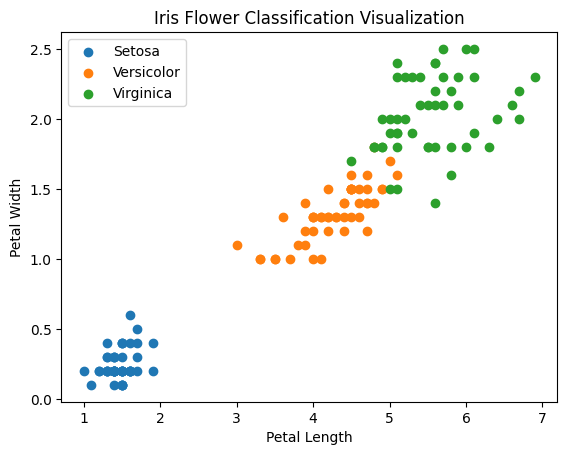

In [47]:
import matplotlib.pyplot as plt

# Separate species
setosa = df[df["Species"] == "Iris-setosa"]
versicolor = df[df["Species"] == "Iris-versicolor"]
virginica = df[df["Species"] == "Iris-virginica"]

# Scatter plot
plt.scatter(setosa["PetalLengthCm"], setosa["PetalWidthCm"], label="Setosa")
plt.scatter(versicolor["PetalLengthCm"], versicolor["PetalWidthCm"], label="Versicolor")
plt.scatter(virginica["PetalLengthCm"], virginica["PetalWidthCm"], label="Virginica")

# Labels and title
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Flower Classification Visualization")

# Legend
plt.legend()

plt.show()

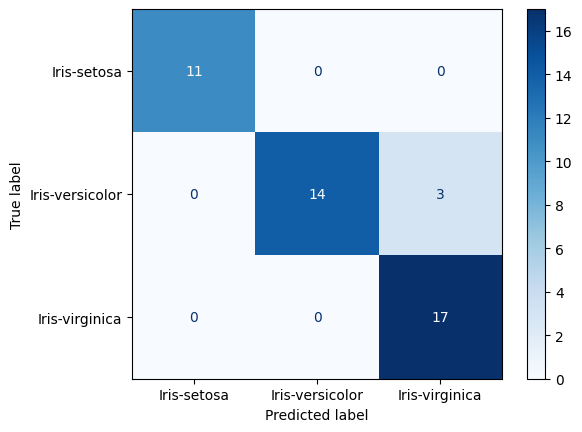

In [65]:
confusion_matrix(y_te, predictions)
ConfusionMatrixDisplay.from_estimator(model, X_te, y_te,cmap='Blues')
plt.show()